## Scientific Image

## Import Libraries

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io, transform
from sklearn import preprocessing
import joblib
import cv2
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import PassiveAggressiveClassifier
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
from skimage.io import imread

## Data Importing

In [5]:
path = r"scientific image 1/data"
model_folder = "model"
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
categories

['Blot-Gel', 'Histopathology', 'X-Ray']

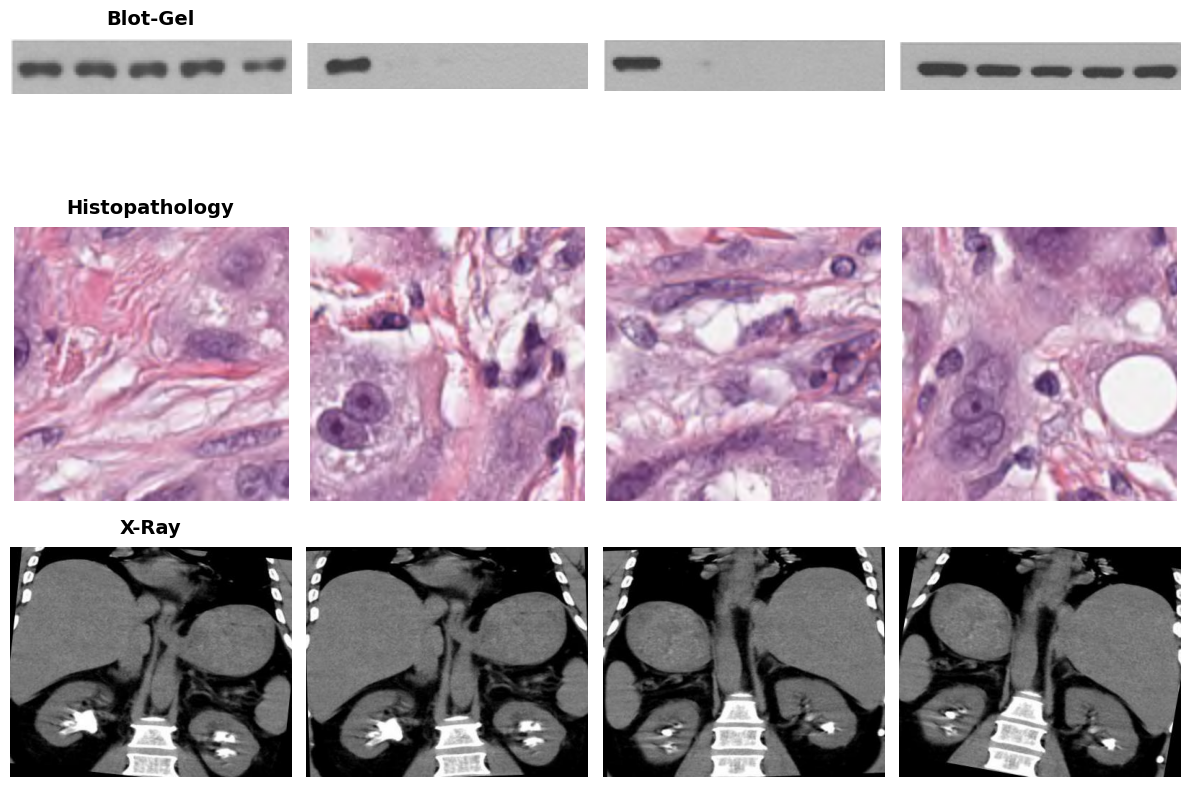

Final image saved at: results\classes_grid.png


In [6]:
num_classes = len(categories)
num_cols = 4  
results_folder = r"results"
os.makedirs(results_folder, exist_ok=True)

plt.figure(figsize=(num_cols * 3, num_classes * 3))

for i, category in enumerate(categories):
    folder_path = os.path.join(path, category)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(("jpg", "jpeg", "png")) and 'Thumbs.db' not in f]
    
    selected_files = files[:4]  
    
    for j, file in enumerate(selected_files):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB
        
        ax = plt.subplot(num_classes, num_cols, i * num_cols + j + 1)
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(category, fontsize=14, weight='bold', pad=10, loc='center')

plt.tight_layout()
output_path = os.path.join(results_folder, "classes_grid.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Final image saved at: {output_path}")

## Preprocessing

In [7]:
# File paths
X_file = os.path.join(model_folder, "X.npz")
Y_file = os.path.join(model_folder, "Y.npz")

# Load if already exists
if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)['arr_0']
    Y = np.load(Y_file)['arr_0']
    print(f"Loaded X and Y from {model_folder}")
else:
    print("Augmenting and creating dataset...")

    X = []
    Y = []



    augment_factor = 20  # Number of augmented images per original

    for category in categories:
        folder_path = os.path.join(path, category)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(("jpg", "png", "jpeg")) and 'Thumbs.db' not in f]

        for file in files:
            img_path = os.path.join(folder_path, file)
            print(img_path)
            img = cv2.imread(img_path)
            img = resize(img, (64, 64, 3))
            img_array = np.expand_dims(img, axis=0)

            # Original image
            X.append(img.flatten())
            Y.append(categories.index(category))


    X = np.array(X)
    Y = np.array(Y)

    # Save as npz
    np.savez_compressed(X_file, X)
    np.savez_compressed(Y_file, Y)
    print(f"Augmented dataset saved to {model_folder}")

print("Dataset shape:", X.shape, Y.shape)

Augmenting and creating dataset...
scientific image 1/data\Blot-Gel\010207.png
scientific image 1/data\Blot-Gel\010208.png
scientific image 1/data\Blot-Gel\010209.png
scientific image 1/data\Blot-Gel\010210.png
scientific image 1/data\Blot-Gel\010211.png
scientific image 1/data\Blot-Gel\010212.png
scientific image 1/data\Blot-Gel\010213.png
scientific image 1/data\Blot-Gel\010214.png
scientific image 1/data\Blot-Gel\010215.png
scientific image 1/data\Blot-Gel\010216.png
scientific image 1/data\Blot-Gel\010217.png
scientific image 1/data\Blot-Gel\010300 (2).png
scientific image 1/data\Blot-Gel\010300 (3).png
scientific image 1/data\Blot-Gel\010300 (4).png
scientific image 1/data\Blot-Gel\010300 (5).png
scientific image 1/data\Blot-Gel\010300 (6).png
scientific image 1/data\Blot-Gel\010300.png
scientific image 1/data\Blot-Gel\010301 (2).png
scientific image 1/data\Blot-Gel\010301 (3).png
scientific image 1/data\Blot-Gel\010301 (4).png
scientific image 1/data\Blot-Gel\010301 (5).png
scien

In [8]:
df = pd.DataFrame(X)
df['Labels'] = Y
df

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,Labels
0,0.980399,0.980399,0.980399,0.967356,0.967356,0.967356,0.968133,0.968133,0.968133,0.968395,...,0.717999,0.717999,0.717999,0.725019,0.725019,0.725019,0.725701,0.725701,0.725701,0
1,0.784234,0.784234,0.784234,0.716695,0.716695,0.716695,0.701368,0.701368,0.701368,0.705733,...,0.706464,0.706464,0.706464,0.706910,0.706910,0.706910,0.709945,0.709945,0.709945,0
2,0.853167,0.853167,0.853167,0.792558,0.792558,0.792558,0.785698,0.785698,0.785698,0.782874,...,0.691738,0.691738,0.691738,0.695399,0.695399,0.695399,0.695453,0.695453,0.695453,0
3,0.818754,0.818754,0.818754,0.754965,0.754965,0.754965,0.747067,0.747067,0.747067,0.752073,...,0.683776,0.683776,0.683776,0.686756,0.686756,0.686756,0.689624,0.689624,0.689624,0
4,0.819963,0.819963,0.819963,0.832118,0.832118,0.832118,0.830156,0.830156,0.830156,0.825290,...,0.694069,0.694069,0.694069,0.696135,0.696135,0.696135,0.682110,0.682110,0.682110,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
1496,0.100343,0.100343,0.100343,0.352575,0.352575,0.352575,0.281647,0.281647,0.281647,0.043335,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2
1497,0.010518,0.010518,0.010518,0.017568,0.017568,0.017568,0.154826,0.154826,0.154826,0.265852,...,0.040438,0.040438,0.040438,0.042980,0.042980,0.042980,0.043137,0.043137,0.043137,2
1498,0.370939,0.370939,0.370939,0.402479,0.402479,0.402479,0.435150,0.435150,0.435150,0.475040,...,0.259450,0.259450,0.259450,0.049474,0.049474,0.049474,0.007199,0.007199,0.007199,2


In [9]:
Y

array([0, 0, 0, ..., 2, 2, 2], shape=(1500,))

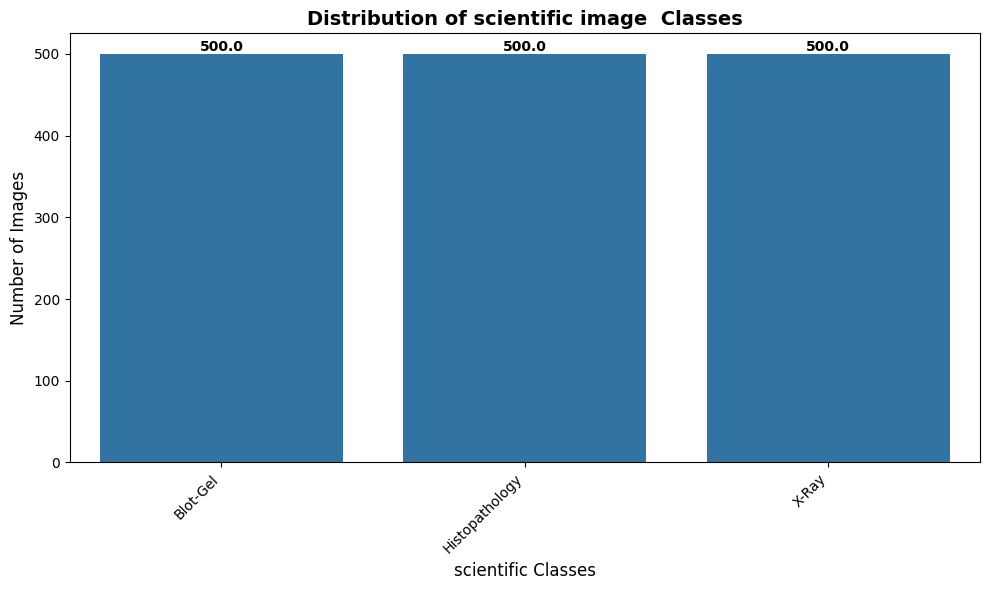

In [10]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=Y)

# Replace x-ticks with class names automatically
ax.set_xticklabels(categories, rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("scientific Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of scientific image  Classes", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## Data Splitting

In [11]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=77)

## Function to Calculate Metrics

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix

# ──────────────────────────────────────────────────────────────
# Global containers
# ──────────────────────────────────────────────────────────────
metrics_overall = []                    # Overall metrics
class_metrics_storage = {}              # Key = class name → list of dicts (one per model)

def calculateMetrics(algorithm, predict, testY):
    """
    Call this for every model (RFC, DTC, NBC, etc.)
    """
    testY = testY.astype('int')
    predict = predict.astype('int')

    # ── Overall metrics ─────────────────────────────────────
    acc  = accuracy_score(testY, predict) * 100
    prec = precision_score(testY, predict, average='macro', zero_division=0) * 100
    rec  = recall_score(testY, predict, average='macro', zero_division=0) * 100
    f1   = f1_score(testY, predict, average='macro', zero_division=0) * 100

    metrics_overall.append({
        'Model': algorithm,
        'Accuracy':  round(acc, 2),
        'Precision': round(prec, 2),
        'Recall':    round(rec, 2),
        'F1-Score':  round(f1, 2)
    })

    print(f"\n=== {algorithm} Overall ===")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%\n")

    # ── Class-wise metrics ──────────────────────────────────
    report = classification_report(testY, predict, target_names=categories,
                                  output_dict=True, zero_division=0)

    for cls in categories:
        # Initialize list for this class if first time
        if cls not in class_metrics_storage:
            class_metrics_storage[cls] = []

        class_metrics_storage[cls].append({
            'Model':     algorithm,
            'Precision': round(report[cls]['precision'] * 100, 2),
            'Recall':    round(report[cls]['recall'] * 100, 2),
            'F1-Score':  round(report[cls]['f1-score'] * 100, 2)
        })

    # ── Confusion matrix ────────────────────────────────────
    cm = confusion_matrix(testY, predict)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, cbar=False)
    plt.title(f"{algorithm} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Model Building and Training

## SVM


=== SVM Classifier Overall ===
Accuracy  : 99.33%
Precision : 99.38%
Recall    : 99.32%
F1-Score  : 99.34%



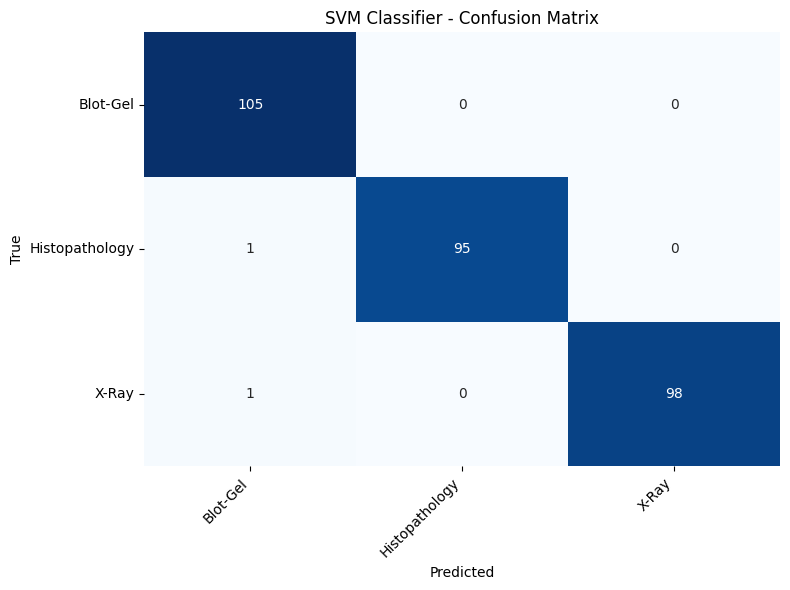

In [13]:
import joblib
import os

model_path = r"model\svm_classifier.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train SVM Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    svm_clf = joblib.load(model_path)
    predict = svm_clf.predict(x_test)
    calculateMetrics("SVM Classifier", predict, y_test)
else:
    svm_clf = SVC()
    svm_clf.fit(x_train, y_train)
    joblib.dump(svm_clf, model_path)

    predict = svm_clf.predict(x_test)
    calculateMetrics("SVM Classifier", predict, y_test)


## LDA


=== LDA Classifier Overall ===
Accuracy  : 87.33%
Precision : 89.04%
Recall    : 87.11%
F1-Score  : 87.47%



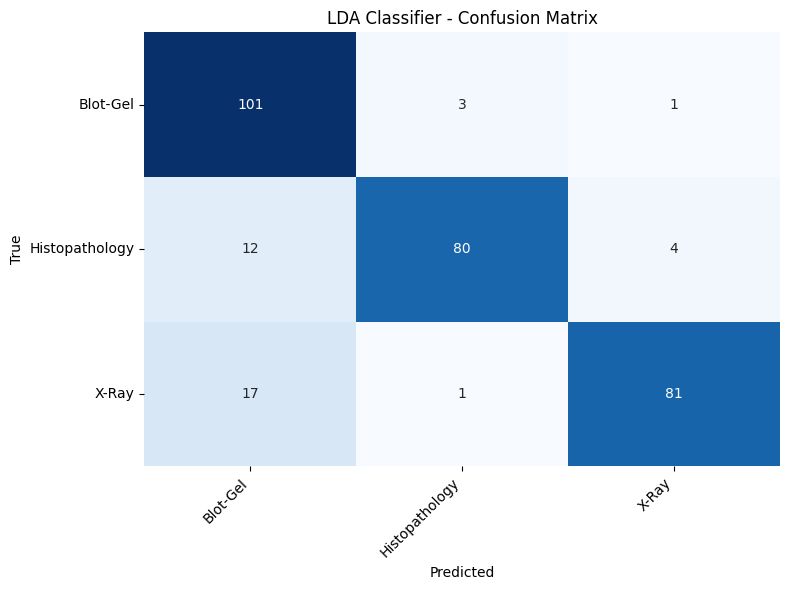

In [14]:
import joblib
import os

model_path = r"model\lda_classifier.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    lda_clf = joblib.load(model_path)
    predict = lda_clf.predict(x_test)
    calculateMetrics("LDA Classifier", predict, y_test)
else:
    lda_clf = LinearDiscriminantAnalysis()
    lda_clf.fit(x_train, y_train)
    joblib.dump(lda_clf, model_path)

    predict = lda_clf.predict(x_test)
    calculateMetrics("LDA Classifier", predict, y_test)


## Ada Boost


=== AdaBoost Classifier Overall ===
Accuracy  : 91.67%
Precision : 92.18%
Recall    : 91.56%
F1-Score  : 91.73%



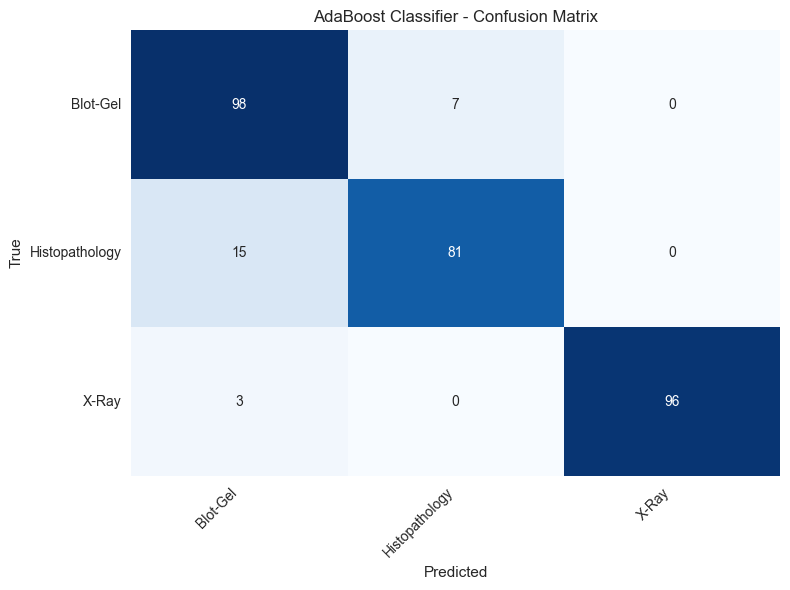

In [18]:
from sklearn.ensemble import AdaBoostClassifier
import joblib
import os

model_path = r"model\adaboost_classifier.pkl"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    ada_clf = joblib.load(model_path)
    predict = ada_clf.predict(x_test)
    calculateMetrics("AdaBoost Classifier", predict, y_test)
else:
    ada_clf = AdaBoostClassifier()
    ada_clf.fit(x_train, y_train)
    joblib.dump(ada_clf, model_path)

    predict = ada_clf.predict(x_test)
    calculateMetrics("AdaBoost Classifier", predict, y_test)


## Performance Comparision

In [16]:
def create_per_class_dataframes():
    if not metrics_overall:
        print("No models evaluated yet!")
        return None

    overall_df = pd.DataFrame(metrics_overall)
    overall_df = overall_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]

    print("\n" + "="*60)
    print("OVERALL MODEL COMPARISON")
    print("="*60)
    print(overall_df.round(4))
    print()

    class_dfs = {}
    for cls, records in class_metrics_storage.items():
        df = pd.DataFrame(records)
        df = df.set_index('Model')[['Precision', 'Recall', 'F1-Score']]

        var_name = cls.replace(" ", "_").replace("-", "_") + "_df"
        globals()[var_name] = df
        class_dfs[cls] = df   # key by original class name (more readable)

        print(f"{cls.upper()} CLASS PERFORMANCE".center(60))
        print("-" * 60)
        print(df.round(4))
        print()

    return overall_df, class_dfs
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 7)

def plot_overall_with_values():
    ax = overall_df.plot(kind='bar', width=0.8, edgecolor='black', alpha=0.9)
    plt.title('Overall Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_per_class_metric_universal(metric_name):
    # Reconstruct correct class names from the original storage (universal!)
    class_names = list(class_metrics_storage.keys())  # e.g., ['Cirriform Clouds', 'Clear Sky', ...]

    # Build DataFrame: rows = models, columns = clean class names
    data = pd.DataFrame()
    for cls in class_names:
        records = class_metrics_storage[cls]
        df = pd.DataFrame(records).set_index('Model')
        data[cls] = df[metric_name]

    # Ensure same model order as overall_df
    data = data.loc[overall_df.index]

    # Plot
    plt.figure()
    ax = data.plot(kind='bar', width=0.82, edgecolor='black', alpha=0.9)

    plt.title(f'{metric_name} per Cloud Class', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel(f'{metric_name} (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Cloud Class', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of every bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9.5, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [17]:
 overall_df, class_dfs = create_per_class_dataframes()


OVERALL MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
SVM Classifier          99.33      99.38   99.32     99.34
LDA Classifier          87.33      89.04   87.11     87.47
AdaBoost Classifier     91.67      92.18   91.56     91.73

                 BLOT-GEL CLASS PERFORMANCE                 
------------------------------------------------------------
                     Precision  Recall  F1-Score
Model                                           
SVM Classifier           98.13  100.00     99.06
LDA Classifier           77.69   96.19     85.96
AdaBoost Classifier      84.48   93.33     88.69

              HISTOPATHOLOGY CLASS PERFORMANCE              
------------------------------------------------------------
                     Precision  Recall  F1-Score
Model                                           
SVM Classifier          100.00   98.96     99.48
LDA Classifier           95.24   83.33   

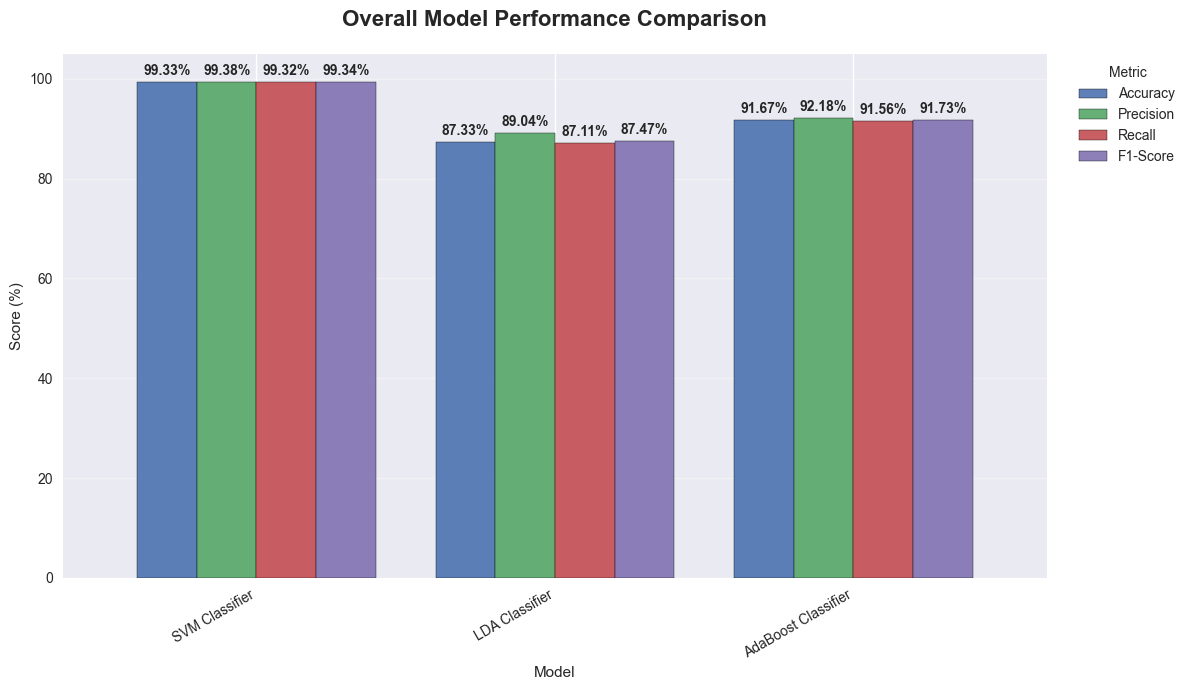

In [19]:
plot_overall_with_values()

## Prediction on Test Image

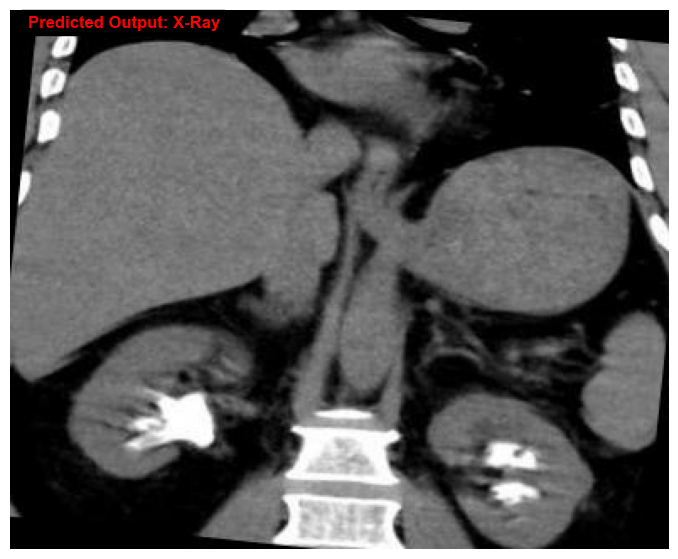

Predicted Class: X-Ray


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.preprocessing.image import load_img

def predict_image(image_path):
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to training size
    img = resize(img, (64, 64, 3), anti_aliasing=True)

    # Flatten (IMPORTANT)
    img_array = img.flatten().reshape(1, -1)

    # Direct prediction (RandomForest returns class number)
    predicted_class = svm_clf.predict(img_array)[0]

    return predicted_class



image_path = r"scientific image 1/data/X-Ray/1-3-46-670589-33-1-63705534437997084400001-5308473522557544550_png_jpg.rf.943c96cc00ce0fb48fc9e1ff65280866.jpg"


# Predict
output_number = predict_image(image_path)
output_name = categories[output_number]

# Show image
img = load_img(image_path)
plt.imshow(img)
plt.text(
    10, 10,
    f'Predicted Output: {output_name}',
    color='red', fontsize=12, weight='bold', backgroundcolor='black'
)
plt.axis('off')
plt.show()

print("Predicted Class:", output_name)
